# PCA Plot

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
pca <- read_table2("data/GWAS_All_Processed_PCA.eigenvec", col_names = F)
eigenval <- scan("data/GWAS_All_Processed_PCA.eigenval")

Warning message:
“`read_table2()` was deprecated in readr 2.0.0.
ℹ Please use `read_table()` instead.”

── Column specification ────────────────────────────────────────────────────────
cols(
  X1 = col_character(),
  X2 = col_character(),
  X3 = col_double(),
  X4 = col_double(),
  X5 = col_double(),
  X6 = col_double(),
  X7 = col_double(),
  X8 = col_double(),
  X9 = col_double(),
  X10 = col_double(),
  X11 = col_double(),
  X12 = col_double()
)



In [3]:
pca <- pca[,-1]
names(pca)[1] <- "ind"
names(pca)[2:ncol(pca)] <- paste0("PC", 1:(ncol(pca)-1))

In [4]:
head(pca)

ind,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MHS_9407758123_R01C01,0.00054791,-0.003757200,-0.01773070,0.047769700,-0.0289836,-0.00278175,0.01446890,0.01123700,0.000190065,-0.03716490
MHS_9407758123_R02C01,0.03091560,0.009805530,0.00247002,-0.043789300,-0.0106826,0.02005620,-0.01817940,0.00152439,-0.036364000,-0.11032000
MHS_9407758123_R03C01,-0.06848060,-0.004744100,-0.02195550,-0.000160842,-0.0511472,-0.05306150,0.07699510,0.03642810,0.042326400,-0.00308846
MHS_9407758123_R04C01,0.03234540,-0.002556780,-0.01671380,0.003174880,-0.0279129,-0.04381150,0.05255320,-0.03471670,0.005052200,-0.02593350
MHS_9407758123_R05C01,0.02817090,0.000536573,0.01796690,-0.060835300,0.0233732,0.07032150,0.04354150,0.08484520,-0.006222240,0.01523940
MHS_9407758123_R06C01,0.00174295,0.005083400,-0.03247800,-0.002461950,-0.0147327,0.03901590,-0.00957361,0.06242180,0.014519600,-0.03945430


In [5]:
pve <- data.frame(PC = 1:10, pve = eigenval/sum(eigenval)*100)

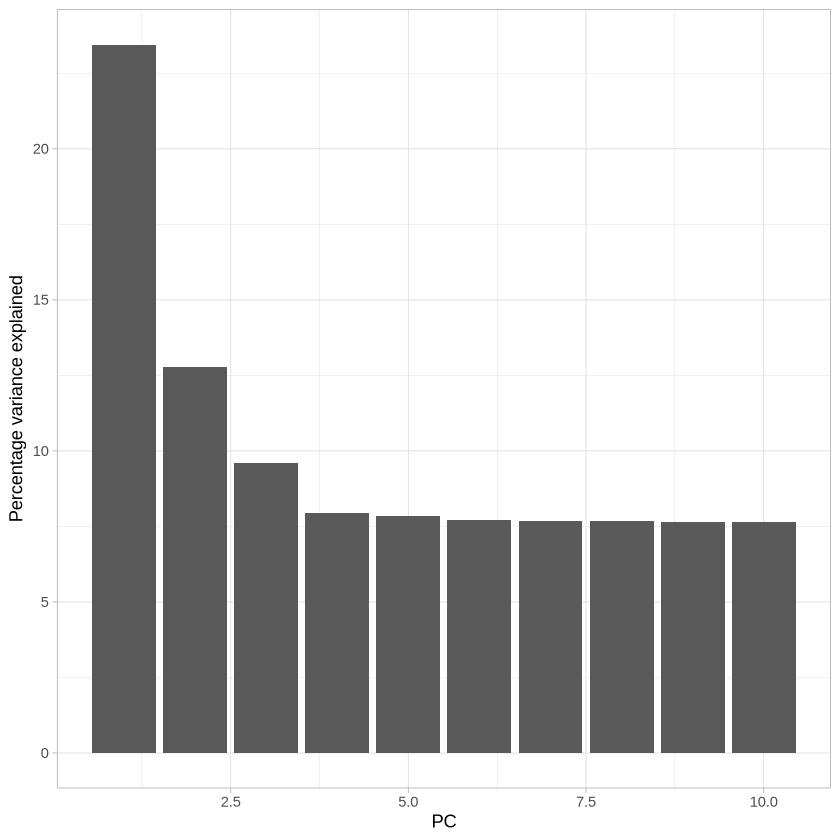

In [6]:
ggplot(pve, aes(PC, pve)) + 
    geom_bar(stat = "identity") + 
    ylab("Percentage variance explained") + 
    theme_light()

In [7]:
# calculate the cumulative sum of the percentage variance explained
cumsum(pve$pve)

[1]  23.45055  36.23630  45.83170  53.77444  61.61841  69.33799  77.02561
 [8]  84.69270  92.35210 100.00000

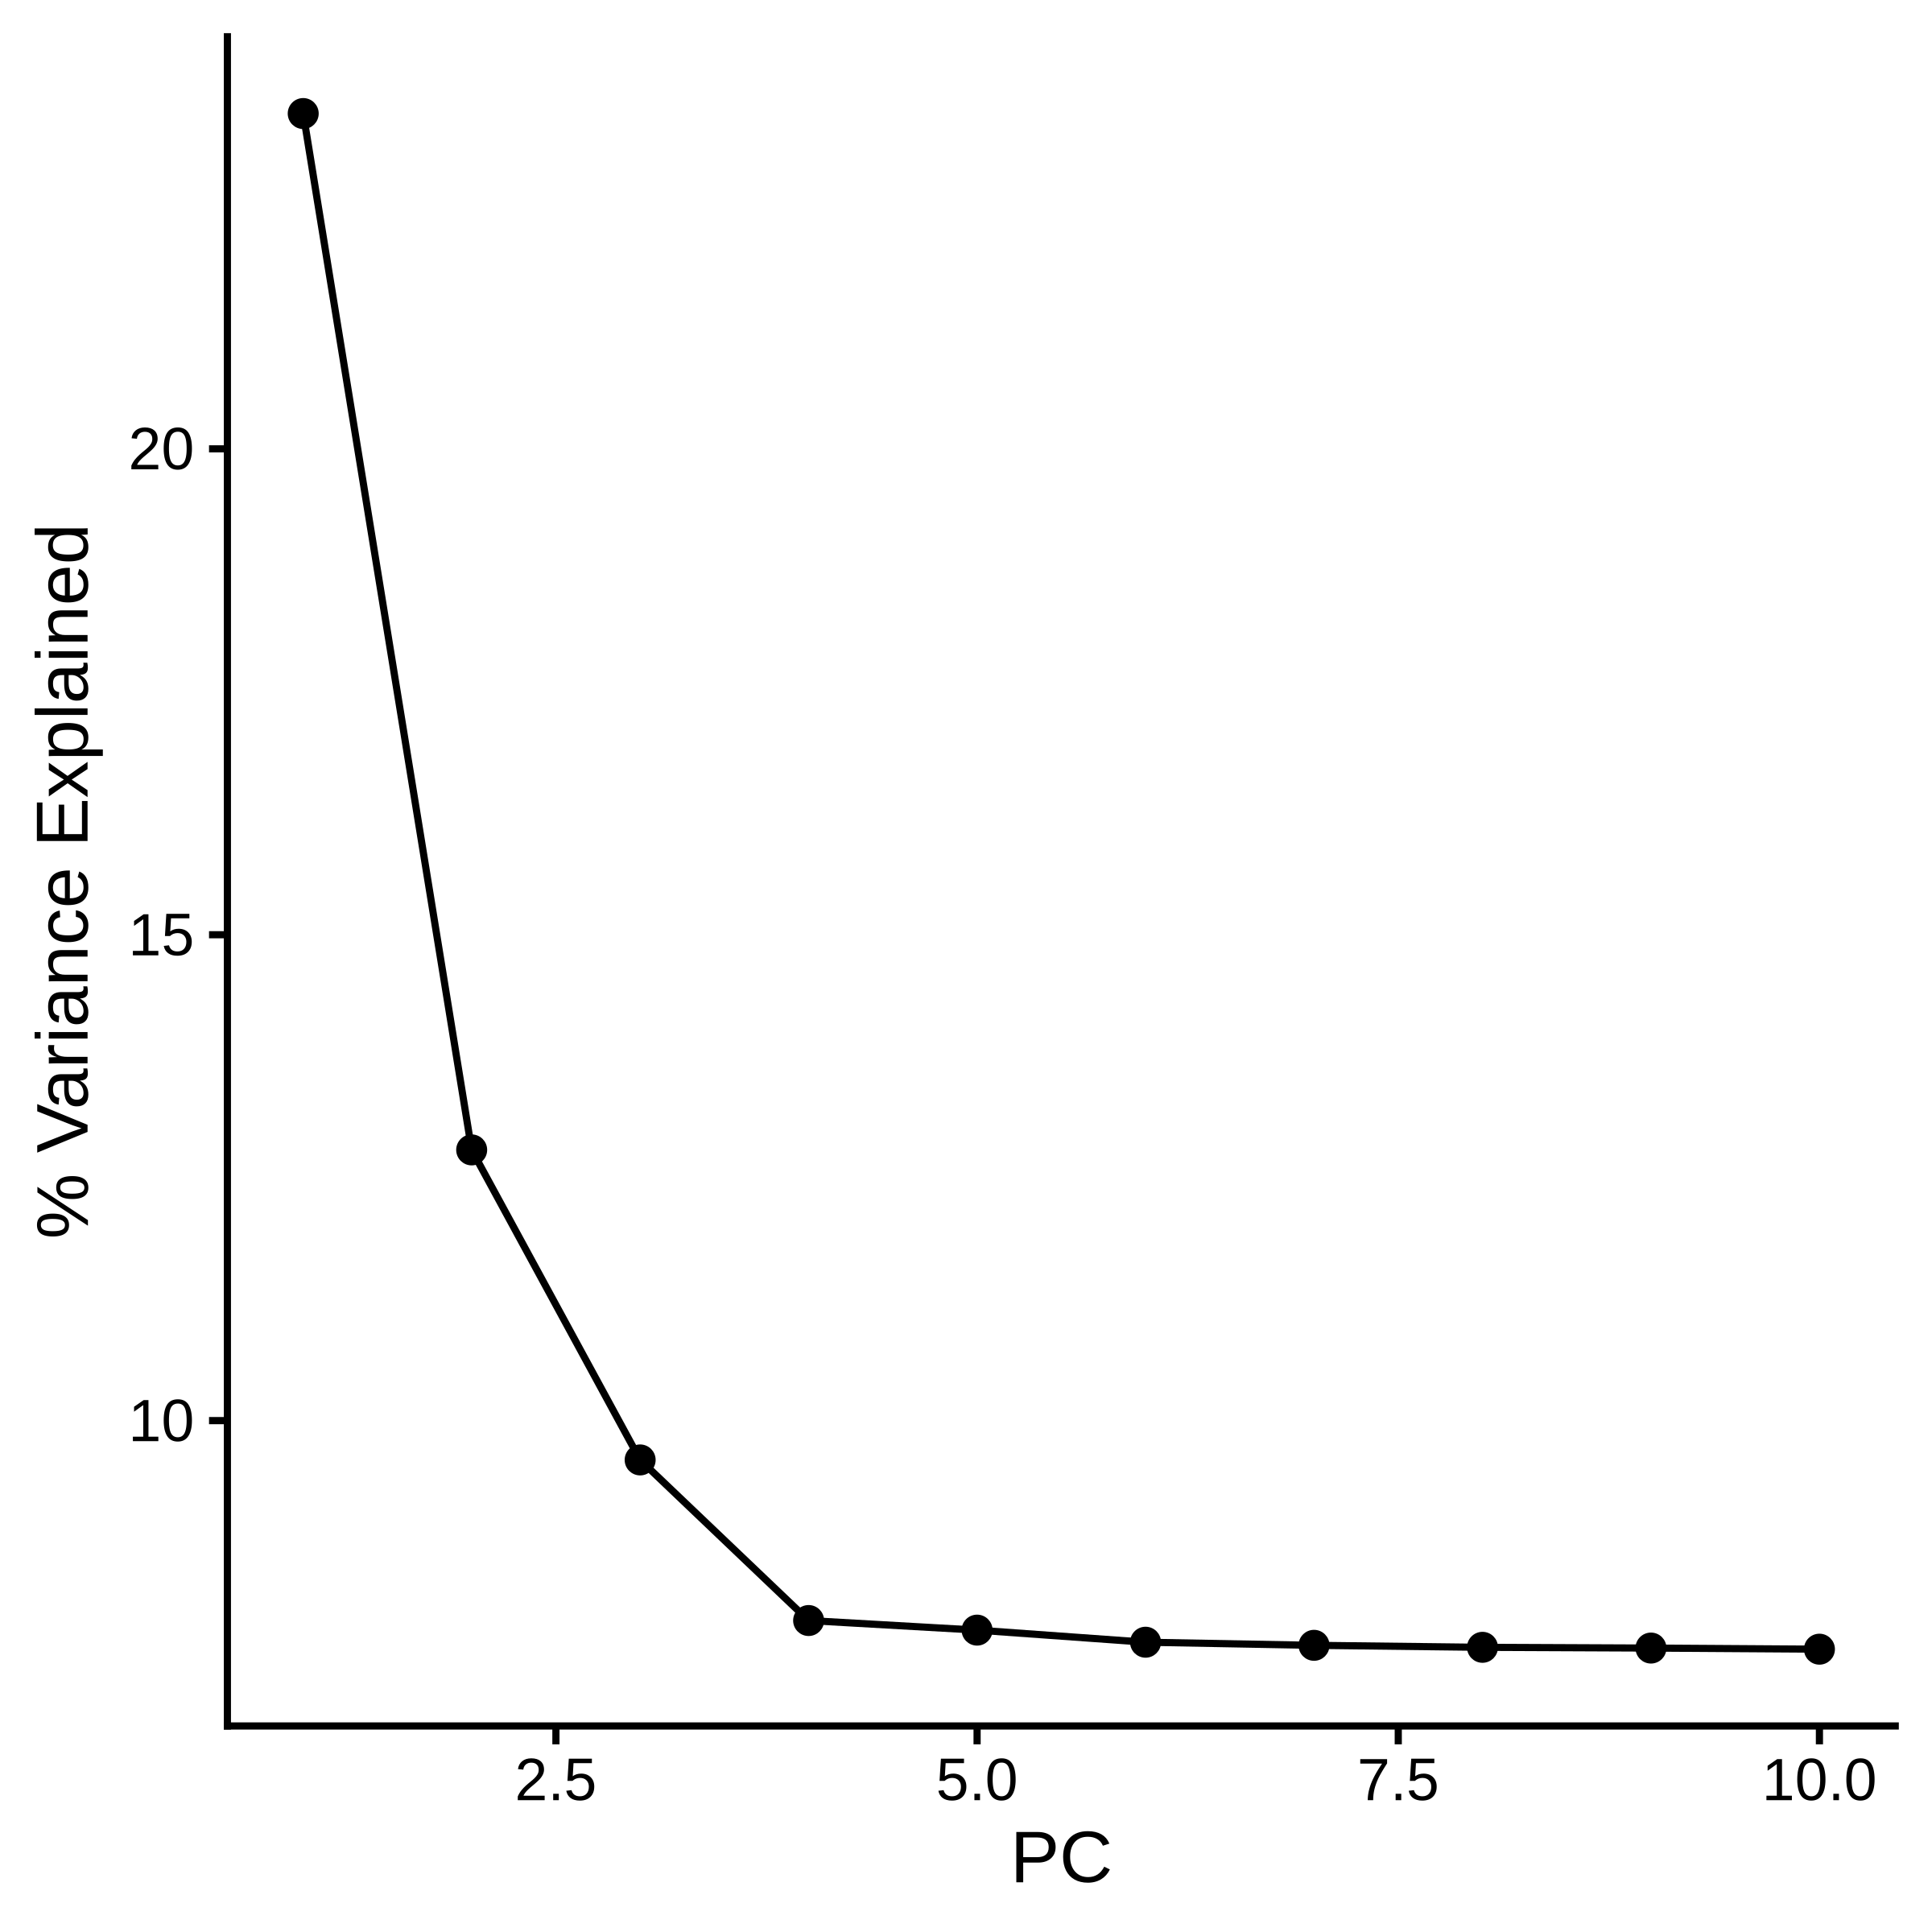

In [8]:
options(repr.plot.width=4, repr.plot.height=4, repr.plot.res =600)
# eigenvalues already loaded
pve <- eigenval / sum(eigenval) * 100

# Plot scree plot to see where it "elbows"
tibble(PC = 1:length(eigenval), PVE = pve) %>%
  ggplot(aes(PC, PVE)) +
  geom_point() +
  geom_line() +
  theme_classic() +
  xlab("PC") +
  ylab("% Variance Explained")

# Q-Q Plot (after using 10 PCs as covariate)

[1] 1.049389

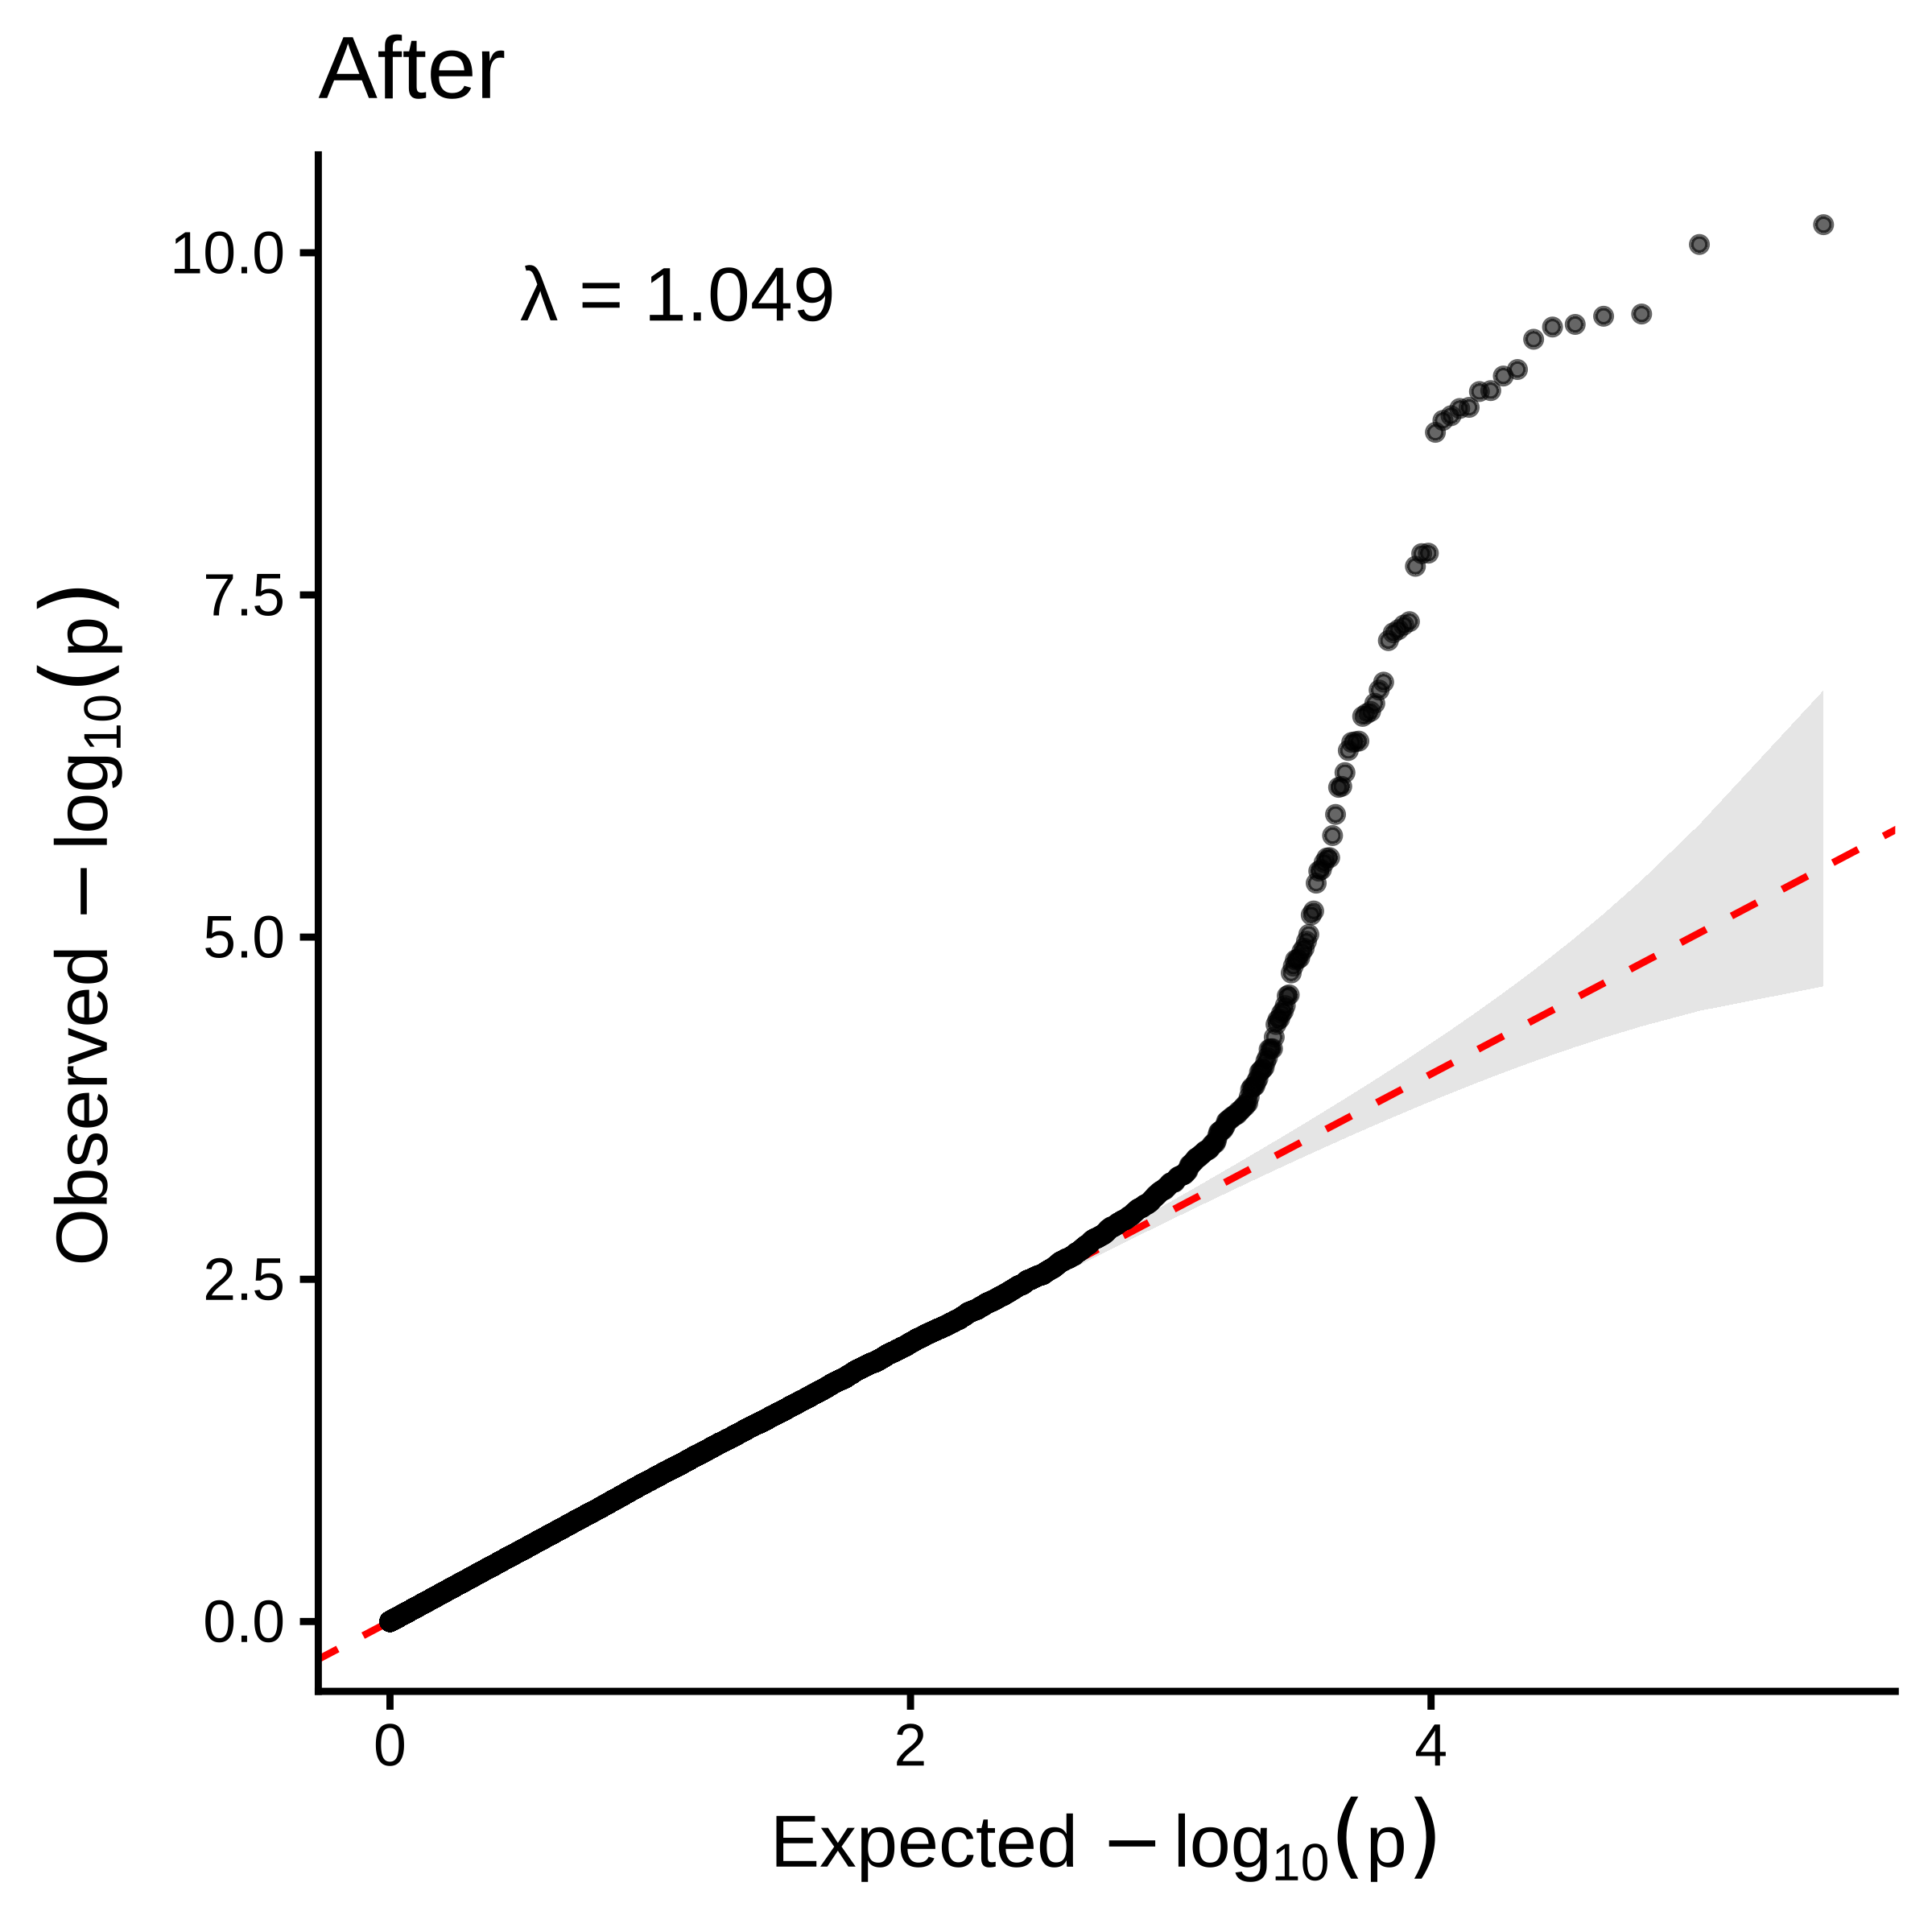

In [11]:
# PLINK output
gwas <- data.table::fread("data/GWAS_LogisticRegression.assoc.logistic")  # or .linear

# ── Filter for ADD only ────────────────────────────────────────────
gwas_add <- gwas %>%
  filter(TEST == "ADD") %>%
  filter(!is.na(P))          # remove any NA p-values

# ── Lambda ────────────────────────────────────────────────────────
chisq  <- qchisq(1 - gwas_add$P, df = 1)
lambda <- median(chisq, na.rm = TRUE) / qchisq(0.5, df = 1)
lambda

# ── QQ Plot ───────────────────────────────────────────────────────
qq_data <- gwas_add %>%
  arrange(P) %>%
  mutate(
    observed = -log10(P),
    expected = -log10(ppoints(n())),
    upper_ci = -log10(qbeta(0.025, 1:n(), n():1)),
    lower_ci = -log10(qbeta(0.975, 1:n(), n():1))
  )

ggplot(qq_data, aes(x = expected, y = observed)) +
  geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci),
              fill = "grey80", alpha = 0.5) +
  geom_abline(intercept = 0, slope = 1,
              colour = "red", linetype = "dashed") +
  geom_point(size = 0.8, alpha = 0.6) +
  annotate("text",
           x     = 0.5,
           y     = max(qq_data$observed) * 0.95,
           label = paste0("λ = ", round(lambda, 3)),
           size  = 4, hjust = 0) +
  labs(
    title = "After",
    x     = expression(Expected ~ -log[10](p)),
    y     = expression(Observed ~ -log[10](p))
  ) +
  theme_classic()

# Q-Q Plot (before using 10 PCs as covariate)

[1] 2.530443

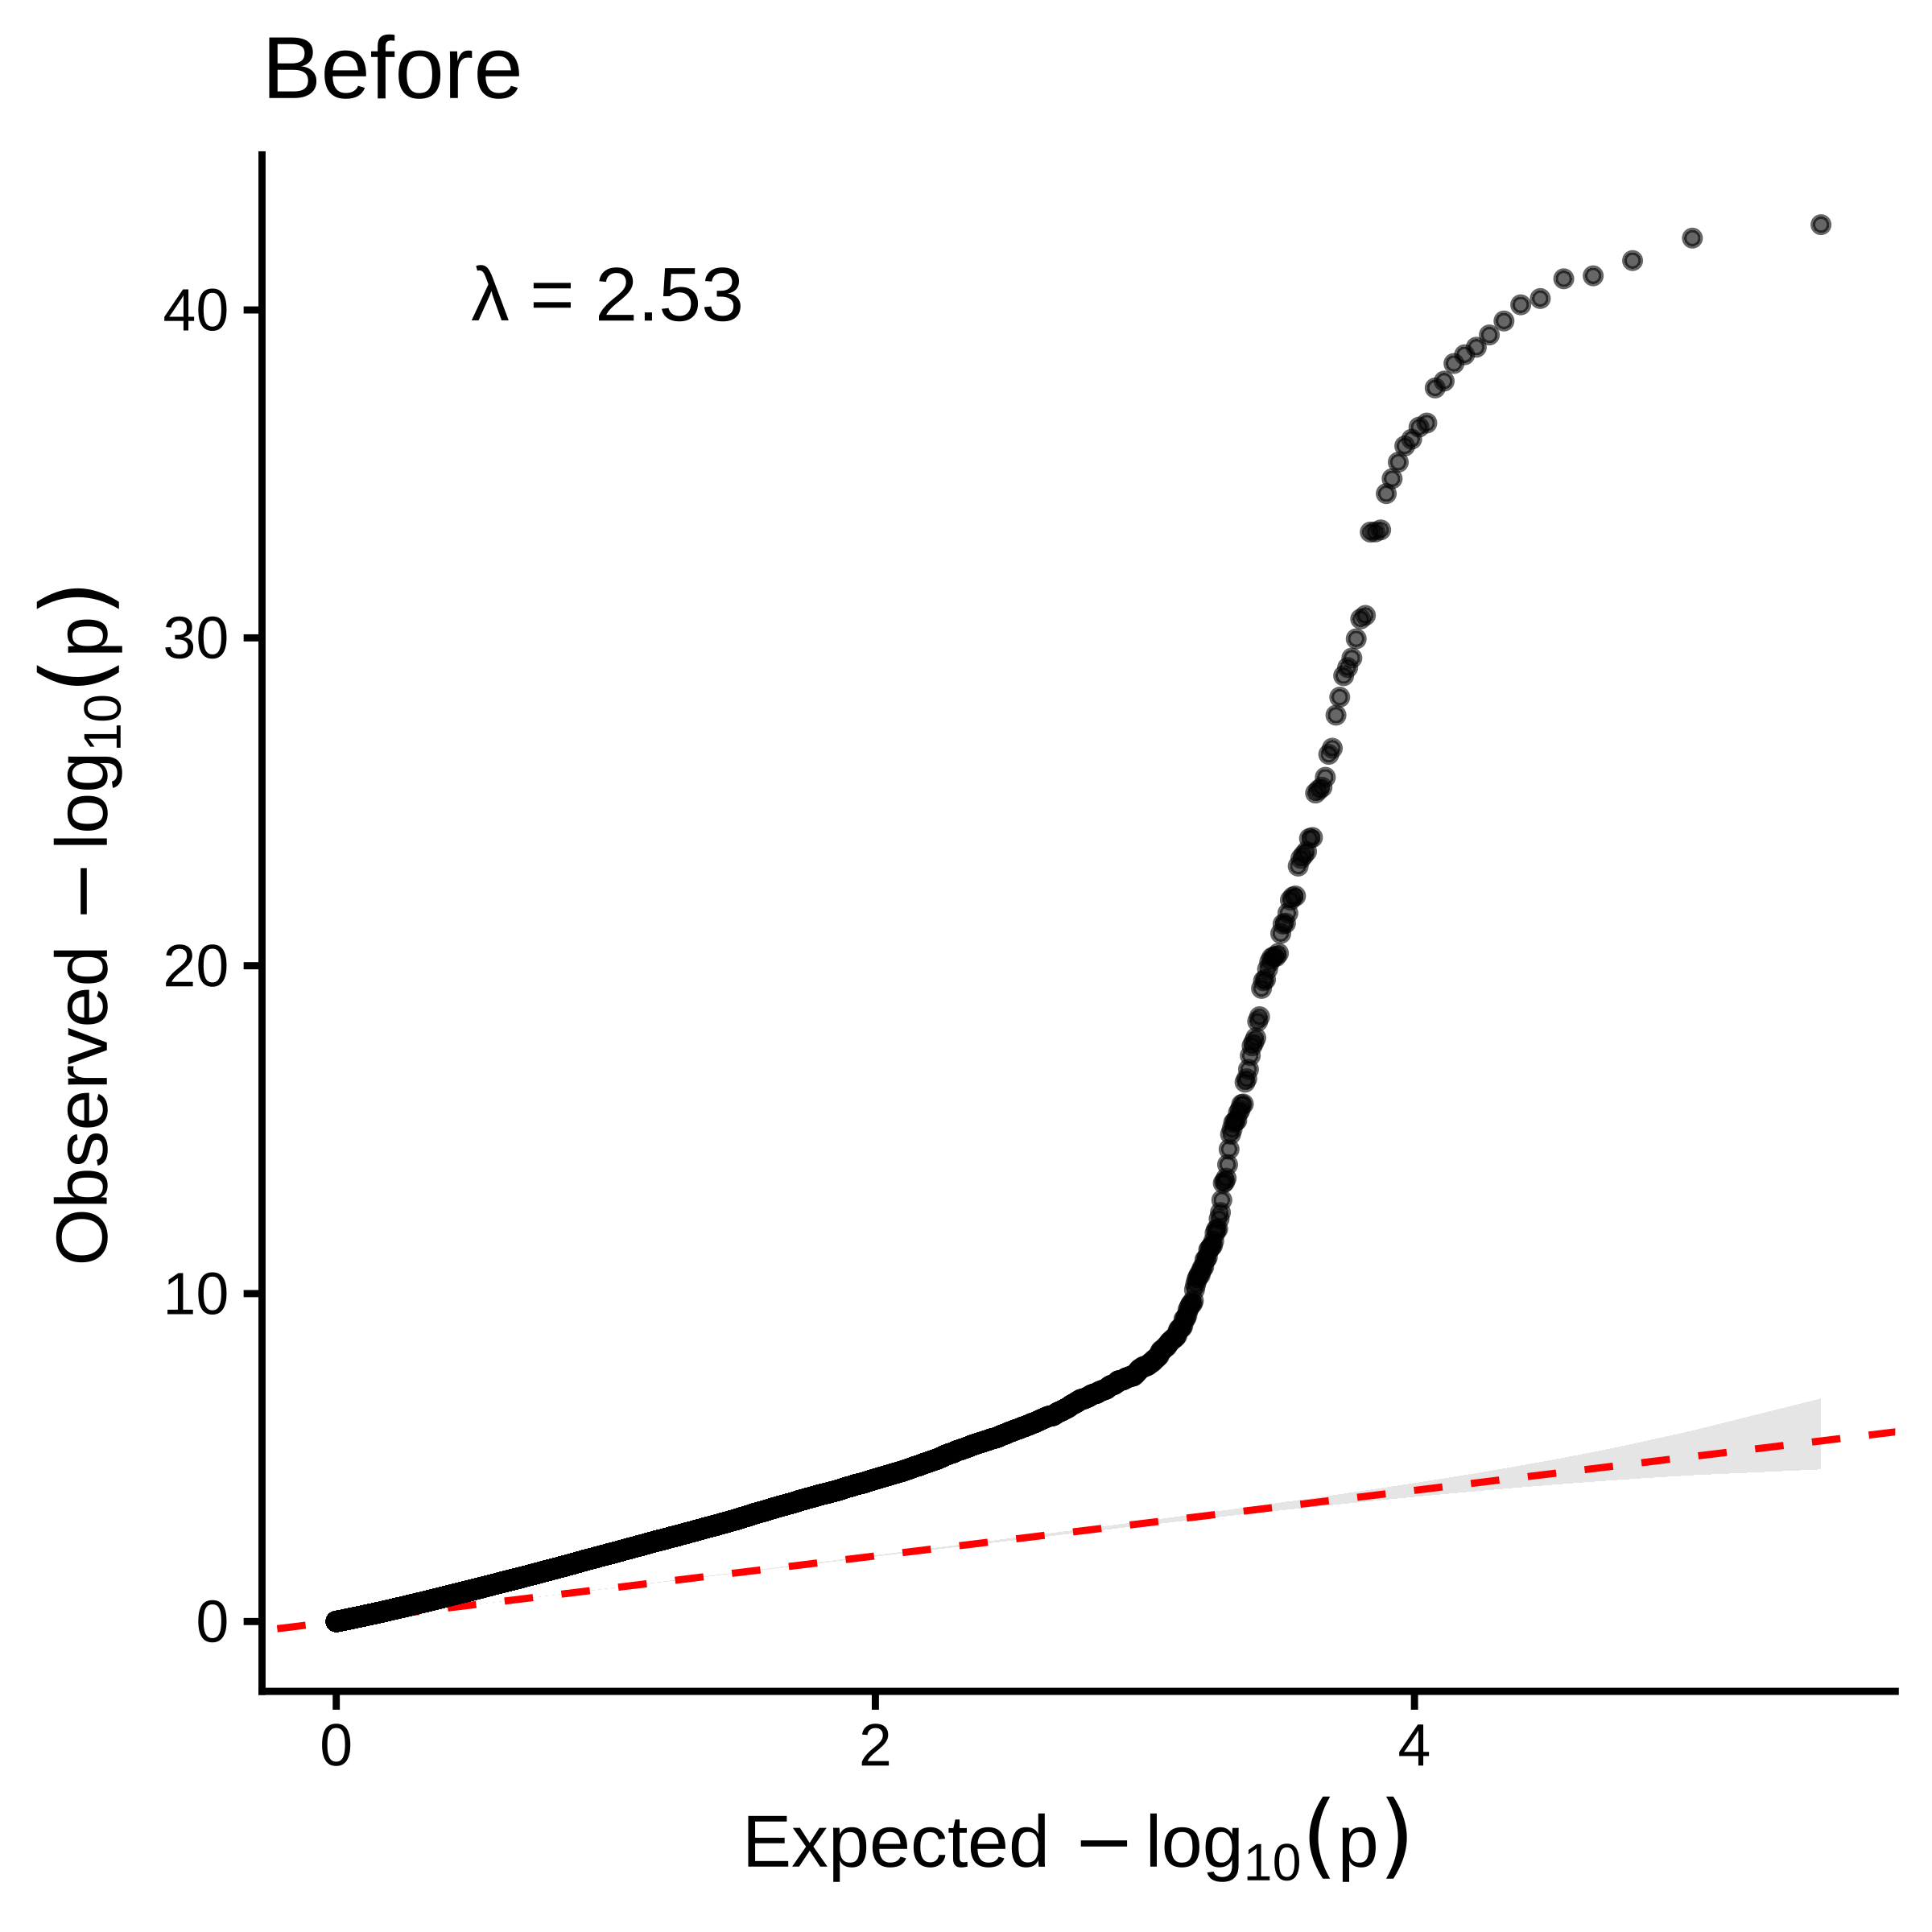

In [12]:
gwas <- data.table::fread("reviewing/GWAS_LogisticRegression_NoCovar.assoc.logistic")  # or .linear

# ── Filter for ADD only ────────────────────────────────────────────
gwas_add <- gwas %>%
  filter(TEST == "ADD") %>%
  filter(!is.na(P))          # remove any NA p-values

# ── Lambda ────────────────────────────────────────────────────────
chisq  <- qchisq(1 - gwas_add$P, df = 1)
lambda <- median(chisq, na.rm = TRUE) / qchisq(0.5, df = 1)
lambda

# ── QQ Plot ───────────────────────────────────────────────────────
qq_data <- gwas_add %>%
  arrange(P) %>%
  mutate(
    observed = -log10(P),
    expected = -log10(ppoints(n())),
    upper_ci = -log10(qbeta(0.025, 1:n(), n():1)),
    lower_ci = -log10(qbeta(0.975, 1:n(), n():1))
  )

ggplot(qq_data, aes(x = expected, y = observed)) +
  geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci),
              fill = "grey80", alpha = 0.5) +
  geom_abline(intercept = 0, slope = 1,
              colour = "red", linetype = "dashed") +
  geom_point(size = 0.8, alpha = 0.6) +
  annotate("text",
           x     = 0.5,
           y     = max(qq_data$observed) * 0.95,
           label = paste0("λ = ", round(lambda, 3)),
           size  = 4, hjust = 0) +
  labs(
    title = "Before",
    x     = expression(Expected ~ -log[10](p)),
    y     = expression(Observed ~ -log[10](p))
  ) +
  theme_classic()